# Mapping the toroid field -- and keeping it numerically stable
### Ampere says $B=\mu_0 N I/(2\pi s)$ inside, $0$ outside; Biot-Savart confirms it

A toroidal solenoid **confines its magnetic field entirely inside the windings**:
Ampere's law gives $B=\mu_0 N I/(2\pi s)$ within the tube (s = distance from the
central axis) and exactly zero outside. We map that field by brute-force Biot-Savart
over the winding and watch the confinement appear. The catch is **numerical
stability**: the Biot-Savart integrand goes as $1/r^3$, so it blows up when a field
point sits on a wire -- we guard it by masking points within a minimum distance of
any segment. The companion `scripts/toroid_field.c` runs the same kernel in C (the
right language for this tight loop). Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from griffiths import magnetostatics as ms

R, a, N, I = 0.5, 0.08, 48, 2.0           # major radius, tube radius, turns, current
MU0 = ms.MU0_SI
loops = ms.toroid_loops(R, a, N, n=48)

# precompute all winding segments once (the fast path for many field points)
def build_segments(loops):
    dls, mids = [], []
    for lp in loops:
        dls.append(np.diff(lp, axis=0)); mids.append(0.5*(lp[:-1]+lp[1:]))
    return np.vstack(dls), np.vstack(mids)
SEG_DL, SEG_MID = build_segments(loops)

def field(p):
    sep = np.asarray(p, float) - SEG_MID
    dist = np.linalg.norm(sep, axis=1)
    near = dist.min()                                   # distance to nearest wire
    B = MU0*I/(4*np.pi) * (np.cross(SEG_DL, sep)/dist[:,None]**3).sum(0)
    return B, near
print(f"toroid: {N} turns, {len(SEG_MID)} segments; Ampere B at s=R: {MU0*N*I/(2*np.pi*R)*1e6:.1f} uT")

toroid: 48 turns, 2256 segments; Ampere B at s=R: 38.4 uT


## 1. Radial profile -- the field lives only in the tube

Scan $|B|$ along the $+x$ axis ($z=0$) from the center out. It is zero until we
enter the tube ($R-a<s<R+a$), where it follows $\mu_0 N I/(2\pi s)$ (the $1/s$
Ampere law), then drops back to zero outside. Points within $0.3a$ of the wire are
**masked** (the stability guard).

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\mrjel\AppData\Local\Temp\ipykernel_66232\3350384471.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(ss, np.array(Bamp)*1e6, "--", label="Ampere $\mu_0 N I/(2\pi s)$")


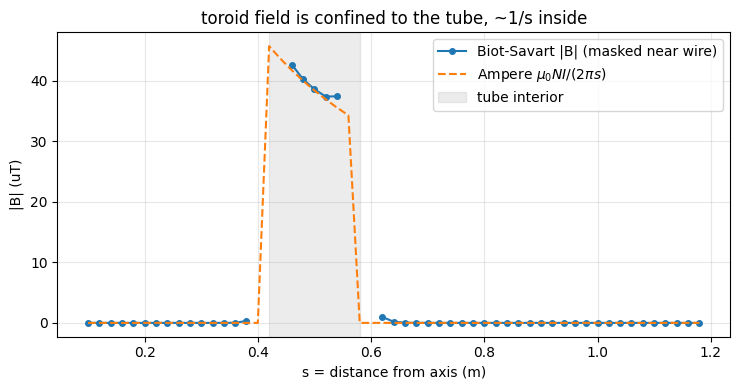

In [2]:
ss = np.arange(0.1, 1.2, 0.02)
Bmag, Bamp = [], []
for s in ss:
    B, near = field([s, 0, 0])
    Bmag.append(np.nan if near < 0.3*a else np.linalg.norm(B))
    Bamp.append(MU0*N*I/(2*np.pi*s) if (R-a < s < R+a) else 0.0)
plt.figure(figsize=(7.5,4))
plt.plot(ss, np.array(Bmag)*1e6, "o-", ms=4, label="Biot-Savart |B| (masked near wire)")
plt.plot(ss, np.array(Bamp)*1e6, "--", label="Ampere $\mu_0 N I/(2\pi s)$")
plt.axvspan(R-a, R+a, color="gray", alpha=0.15, label="tube interior")
plt.xlabel("s = distance from axis (m)"); plt.ylabel("|B| (uT)"); plt.legend()
plt.title("toroid field is confined to the tube, ~1/s inside"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. 2D field map over the cross-section

Now $|B|$ over the $x$-$z$ plane (the plane containing the toroid axis). The torus
cuts this plane in **two tube cross-sections** (at $x=\pm R$); inside each the field
is strong (pointing azimuthally, in/out of the page), and everywhere else it is dark.
Grid points within $0.3a$ of a wire are masked (shown white) -- without that guard the
$1/r^3$ singularity would paint huge fake spikes.

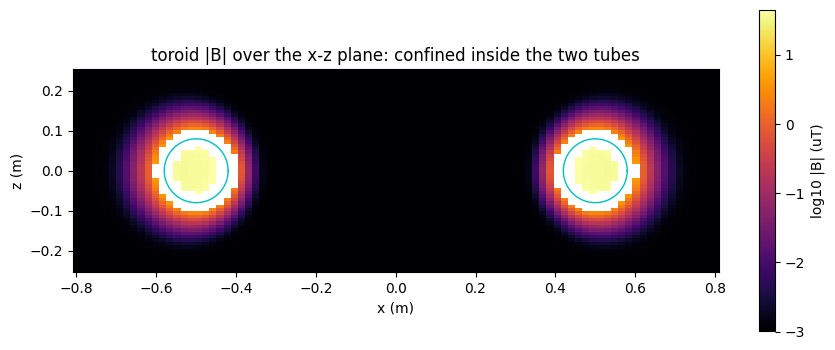

field is bright inside the tube circles, dark (near zero) everywhere else


In [3]:
xs = np.linspace(-0.8, 0.8, 90); zs = np.linspace(-0.25, 0.25, 60)
Bmap = np.full((len(zs), len(xs)), np.nan)
for iz, z in enumerate(zs):
    for ix, x in enumerate(xs):
        B, near = field([x, 0, z])
        if near >= 0.3*a:
            Bmap[iz, ix] = np.linalg.norm(B)
plt.figure(figsize=(9,3.6))
pm = plt.pcolormesh(xs, zs, np.log10(Bmap*1e6 + 1e-3), shading="auto", cmap="inferno")
plt.colorbar(pm, label="log10 |B| (uT)")
for cx in (R, -R):                                   # outline the two tube walls
    th = np.linspace(0, 2*np.pi, 100)
    plt.plot(cx + a*np.cos(th), a*np.sin(th), "c-", lw=1)
plt.xlabel("x (m)"); plt.ylabel("z (m)"); plt.title("toroid |B| over the x-z plane: confined inside the two tubes")
plt.gca().set_aspect("equal"); plt.tight_layout(); plt.show()
print("field is bright inside the tube circles, dark (near zero) everywhere else")

## 3. Numerical stability -- the $1/r^3$ guard

Biot-Savart sums $d\boldsymbol\ell\times(\mathbf r-\mathbf r')/|\mathbf r-\mathbf r'|^3$.
As a field point approaches a wire, $|\mathbf r-\mathbf r'|\to0$ and a single term
explodes -- a *numerical* artifact (the real field of a finite-thickness wire is
finite). Two standard cures: **mask** points closer than $d_{\min}$ to any segment
(used here), or give the wire a finite core radius. Either way you report physics,
not a divide-by-almost-zero spike.

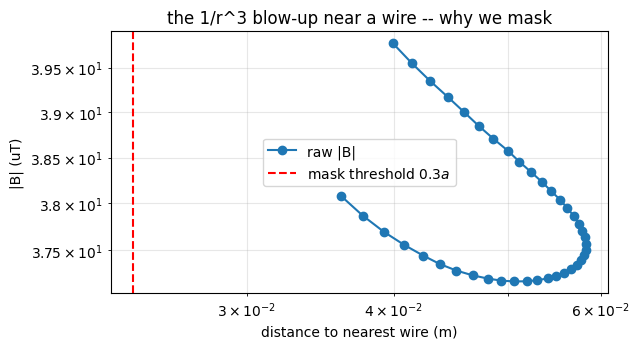

In [4]:
# show the blow-up vs the guard: walk straight toward a wire
target = SEG_MID[np.argmin(np.linalg.norm(SEG_MID - np.array([R,0,0]), axis=1))]
dists, raws = [], []
for f in np.linspace(0.9, 0.001, 40):
    p = np.array([R,0,0]) + f*(target - np.array([R,0,0])) + np.array([0,0, a*0.5])
    B, near = field(p); dists.append(near); raws.append(np.linalg.norm(B))
plt.figure(figsize=(6.5,3.6))
plt.loglog(dists, np.array(raws)*1e6, "o-", label="raw |B|")
plt.axvline(0.3*a, color="r", ls="--", label="mask threshold $0.3a$")
plt.xlabel("distance to nearest wire (m)"); plt.ylabel("|B| (uT)")
plt.title("the 1/r^3 blow-up near a wire -- why we mask"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## What you mapped (and what to code in C)

1. The toroid **confines its field**: $B=\mu_0 N I/(2\pi s)$ inside the tube, $\approx0$
   outside -- the Biot-Savart map reproduces the Ampere law and the $1/s$ profile.
2. **Numerical stability** is the real work: the $1/r^3$ kernel blows up at the wires,
   so mask points within $d_{\min}$ (or use a finite wire core).
3. **What to code in C:** this inner kernel -- *for each field point, sum over every
   wire segment* -- is an $O(\text{points}\times\text{segments})$ double loop. Pure
   Python is fine for a coarse map but slow for a fine 3-D grid; in C the same loop
   (see `scripts/toroid_field.c`) runs ~50-100x faster. That is the canonical
   "drop to C" case: a tight, regular, floating-point inner loop. Civilian education.